# Data Science Internship – Task 4
## Mini Visualization Dashboard (Titanic Dataset)

## Overview

This notebook presents a mini visualization dashboard using the Titanic dataset.
We analyze survival patterns using data cleaning, feature engineering, and visualizations.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load Dataset

We load the Titanic dataset for analysis.

In [8]:
df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Data Cleaning

- Fill missing Age values
- Fill missing Embarked values
- Drop Cabin column

In [10]:
df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

df.isnull().sum()

C:\Users\Bhumika Patil\AppData\Local\Temp\ipykernel_9136\3096012216.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

## Feature Engineering

- Create `age_group`
- Create `family_size`

In [12]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

df['family_size'] = df['sibsp'] + df['parch']

## Mini Visualization Dashboard

This dashboard presents multiple visualizations in a clean and aligned layout for better understanding of Titanic survival patterns.rvival

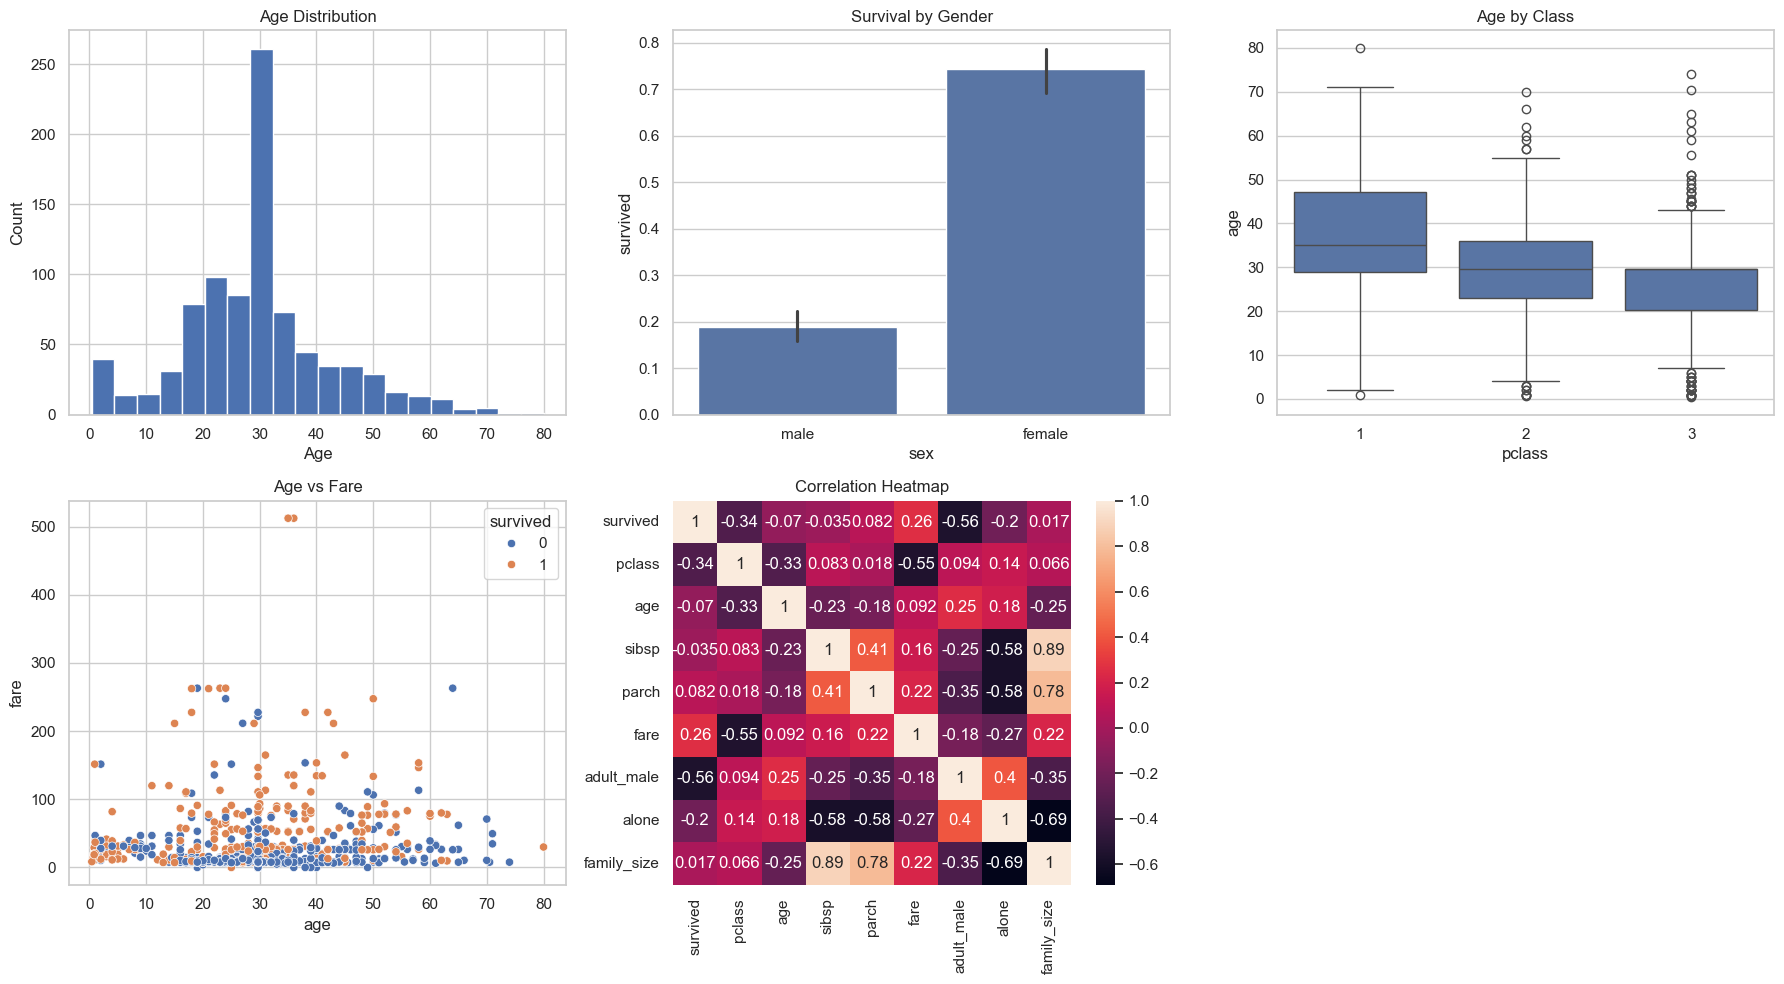

In [14]:
# Create figure with proper size
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Adjust spacing
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# -------------------------------
# 1. Age Distribution
# -------------------------------
axes[0, 0].hist(df['age'], bins=20)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

# -------------------------------
# 2. Survival by Gender
# -------------------------------
sns.barplot(x='sex', y='survived', data=df, ax=axes[0, 1])
axes[0, 1].set_title("Survival by Gender")

# -------------------------------
# 3. Age by Passenger Class
# -------------------------------
sns.boxplot(x='pclass', y='age', data=df, ax=axes[0, 2])
axes[0, 2].set_title("Age by Class")

# -------------------------------
# 4. Age vs Fare
# -------------------------------
sns.scatterplot(x='age', y='fare', hue='survived', data=df, ax=axes[1, 0])
axes[1, 0].set_title("Age vs Fare")

# -------------------------------
# 5. Correlation Heatmap
# -------------------------------
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap")

# -------------------------------
# 6. Hide empty subplot (for symmetry)
# -------------------------------
axes[1, 2].axis('off')

# Final layout
plt.tight_layout()
plt.show()

## Dashboard Insights

- Female passengers had higher survival rates
- Higher-class passengers survived more
- Higher fare increased survival probability
- Most passengers were young adults
- Strong relationship between fare, class, and survival